# Code to Analyze and Visualize Experimental Data

This notebook provides code to generate figures and data included in the manuscript.

Please correctly locate the file path before running the sequent codes.

In [ ]:
import os

# Gets the directory where the current Notebook file is located
notebook_dir = os.path.dirname(os.path.abspath("__file__"))

# Use %cd to switch to this directory
%cd $notebook_dir

## Test Example of the Artificial Program


### Motivation Example

Before running the code to plot the figure, the following files should be appended to the current path.
+ `shots=1000_MW Test.csv`
+ `shots=10000_MW Test.csv`
+ `shots=100000_MW Test.csv`

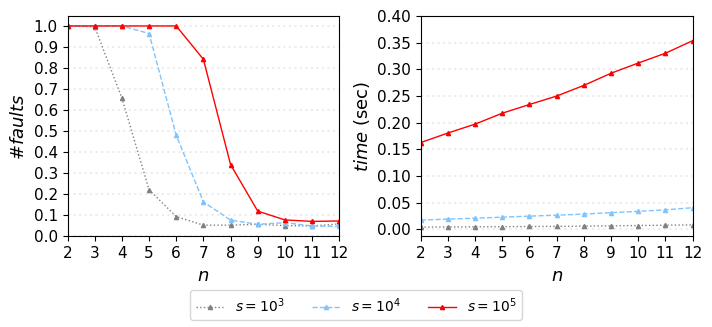

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math 

shots_list = [1000, 10000, 100000]

# arguments for the figure
fontsize = 13
labelsize = 11
linewidth = 1
markersize = 3
figsize = (10, 3.5)
colors = ['grey', '#7FC4FD', 'red']
marker = '^'
linestyles = [':', '--', '-']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
for i, shots in enumerate(shots_list):
    # read the .csv files
    file_path = "shots={}_MW Test.csv".format(shots)
    df = pd.read_csv(file_path)
    qubit_list = df.iloc[:, 0]
    fault_list = df.iloc[:, 1]
    time_list = df.iloc[:, 2]
    
    ax1.plot(qubit_list, 
             fault_list, 
             marker=marker, 
             linestyle=linestyles[i], 
             color=colors[i],
             label='$s=10^{}$'.format(int(math.log10(shots))),
             linewidth=linewidth,
             markersize=markersize)
    ax2.plot(qubit_list, 
             time_list, 
             marker=marker, 
             linestyle=linestyles[i], 
             color=colors[i],
             linewidth=linewidth,
             markersize=markersize)    
    
    ax1.set_ylabel('#$faults$', color='black', fontsize=fontsize)
    ax1.tick_params(axis='y', labelcolor='black', labelsize=labelsize)
    ax1.tick_params(axis='x', labelcolor='black', labelsize=labelsize)
    ax2.set_ylabel('$time$ (sec)', color='black', fontsize=fontsize)
    ax2.tick_params(axis='y', labelcolor='black', labelsize=labelsize)
    ax2.tick_params(axis='x', labelcolor='black', labelsize=labelsize) 

ax1.set_xlim(2, 12)
ax1.set_xticks(np.arange(2, 13, 1))
ax2.set_xlim(2, 12)
ax2.set_xticks(np.arange(2, 13, 1))
ax1.set_xlabel(r'$n$', fontsize=fontsize)
ax2.set_xlabel(r'$n$', fontsize=fontsize)
ax1.set_yticks(np.arange(0, 1.01, 0.1))
ax2.set_yticks(np.arange(0, 0.45, 0.05))

ax1.grid(True, linestyle=':', color='gray', linewidth=1.5, alpha=0.15, axis='y')
ax2.grid(True, linestyle=':', color='gray', linewidth=1.5, alpha=0.15, axis='y')


fig.legend(loc='lower center', ncol=3, fontsize=labelsize-1)
plt.subplots_adjust(wspace=0.3, right=0.75, bottom=0.25)
 
# display the figure
plt.savefig('motivation.pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

### Case Study

Before running the code to plot the figure, the following files should be appended to the current path.
+ `shots=20_MW Test.csv`
+ `shots=100000_MW Test.csv`
+ `shots=20_HOSS.csv`

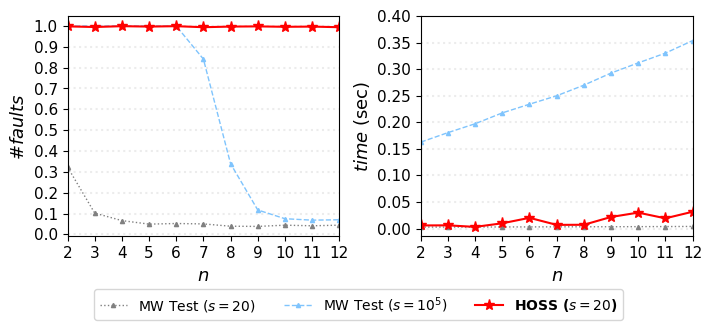

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

shots_list = [20, 100000, 20]
oracles = ['MW Test', 'MW Test', 'HOSS']

# arguments for the figure
fontsize = 13
labelsize = 11
linewidth = 1
markersize = 3
figsize = (10, 3.5)
colors = ['grey', '#7FC4FD', 'red']
markers = ['^', '^', '*']
linestyles = [':', '--', '-']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
for i, shots in enumerate(shots_list):
    # read the .csv files
    file_path = "shots={}_{}.csv".format(shots, oracles[i])
    df = pd.read_csv(file_path)
    qubit_list = df.iloc[:, 0]
    fault_list = df.iloc[:, 1]
    time_list = df.iloc[:, 2]
    
    if i == 0:
        label = 'MW Test ($s=20$)'
    elif i == 1:
        label = 'MW Test ($s=10^5$)'
    elif i == 2:
        label = 'HOSS ($s=20$)'

    if i == 2:
        temp_markersize = markersize + 5
        temp_linewidth = linewidth + 0.5
    else:
        temp_markersize = markersize
        temp_linewidth = linewidth

    ax1.plot(qubit_list, 
             fault_list, 
             marker=markers[i], 
             linestyle=linestyles[i], 
             color=colors[i],
             label=label,
             linewidth=temp_linewidth,
             markersize=temp_markersize)
    ax2.plot(qubit_list, 
             time_list, 
             marker=markers[i], 
             linestyle=linestyles[i], 
             color=colors[i],
             linewidth=temp_linewidth,
             markersize=temp_markersize)    
    
    ax1.set_ylabel('#$faults$', color='black', fontsize=fontsize)
    ax1.tick_params(axis='x', labelcolor='black', labelsize=labelsize)
    ax1.tick_params(axis='y', labelcolor='black', labelsize=labelsize)
    ax2.set_ylabel('$time$ (sec)', color='black', fontsize=fontsize)
    ax2.tick_params(axis='x', labelcolor='black', labelsize=labelsize)
    ax2.tick_params(axis='y', labelcolor='black', labelsize=labelsize) 


ax1.set_xlim(2, 12)
ax1.set_xticks(np.arange(2, 13, 1))
ax2.set_xlim(2, 12)
ax2.set_xticks(np.arange(2, 13, 1))
ax1.set_xlabel(r'$n$', fontsize=fontsize)
ax2.set_xlabel(r'$n$', fontsize=fontsize)
ax1.set_yticks(np.arange(0, 1.01, 0.1))
ax2.set_yticks(np.arange(0, 0.45, 0.05))

ax1.grid(True, linestyle=':', color='gray', linewidth=1.5, alpha=0.15, axis='y')
ax2.grid(True, linestyle=':', color='gray', linewidth=1.5, alpha=0.15, axis='y')

legend = fig.legend(loc='lower center', ncol=3, fontsize=labelsize-1)
legend_texts = legend.get_texts()
legend_texts[-1].set_weight('bold')

plt.subplots_adjust(wspace=0.3, right=0.75, bottom=0.25)

# display the figure
plt.savefig('case_study.pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

## RQ1

### Plot for Variable Shots

The following code aims to yield all the figures (from `v1` to `v5` of `DO`), where these figures show the variation of average detected faults with the shots increase. The figures for `v4` are picked to display in Fig. 8.

Before running the code, the `.csv` files should be appended to the current path. Note that all the following `.csv` files should be traversed.
Format: `aaa_bbb_RQ1_ccc.csv`, where
 
+ `aaa`$\in[$`DO`, `QFT`, `LPR`, `LAF`, `IC`, `WA`$]$, 
+ `bbb`$\in[$`v1`, `v2`, `v3`, `v4`, `v5`$]$, 
+ `ccc`$\in[$`KS Test`, `Chi Squared`, `MW Test`, `JS Div`, `Crs Ent`, `HOSS`$]$. 

Here, taking an example to plot the figure of `DO-v1`, the following files at `\experimental_data\RQ1\raw_data\DO` should be appended to the current file:
+ `DO_v1_RQ1_MW Test.csv`
+ `DO_v1_RQ1_KS Test.csv`
+ `DO_v1_RQ1_JS Div.csv`
+ `DO_v1_RQ1_Crs Ent.csv`
+ `DO_v1_RQ1_HOSS.csv`

It is the same for plotting other versions or QPs.


QP: LPR


FileNotFoundError: [Errno 2] No such file or directory: 'LPR_v1_RQ1_KS Test.csv'

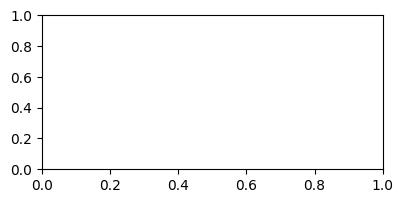

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
 
short_names = ['LPR', 'LAF', 'QFT', 'DO', 'IC', 'WA']
versions = ['v1', 'v2', 'v3', 'v4', 'v5']
oracles = ["KS Test", "Chi Squared", "MW Test", "JS Div", "Crs Ent", "HOSS"]

width = 0.8
fontsize = 13
labelsize = 11
linewidth = 1
figsize_para = (4.4, 2)
 
for index in range(len(short_names)):
    short_name = short_names[index]
    print("QP: {}".format(short_name))

    for version_id, version in enumerate(versions): 
        fig, ax = plt.subplots(1, 1, figsize=figsize_para)
        for col, oracle in enumerate(oracles):
            # read the .csv file
            file_path = short_name + '_' + version + '_RQ1_' + oracle + ".csv"
            df1 = pd.read_csv(file_path)
            x1 = df1.iloc[:, 0]  # the first column: shots
            y1 = df1.iloc[:, 4]  # the fifth column: average faults

            # plot data corresponding to each test oracle
            if oracle == "MW Test":
                ax.plot(x1, y1, label='Mann–Whitney U test', linewidth=linewidth, linestyle='-.', color='#7FC4FD')
            elif oracle == "KS Test":
                ax.plot(x1, y1, label='Kolmogorov-Smirnov test', linewidth=linewidth, linestyle='-.', color='#038BFB')
            elif oracle == "Chi Squared":
                ax.plot(x1, y1, label='Chi-squared test', linewidth=linewidth, linestyle='-.', color='#A065FF')                
            elif oracle == "JS Div":
                ax.plot(x1, y1, label='Jensen–Shannon divergence', linewidth=linewidth, linestyle='--', color='#548235')
            elif oracle == "Crs Ent":
                ax.plot(x1, y1, label='Cross entropy', linewidth=linewidth, linestyle='--',color='#99D600')
            elif oracle == "HOSS":
                ax.plot(x1, y1, label='HOSS', linewidth=linewidth+0.25, linestyle='-',color='red')      
        ax.plot(x1, [25]*len(x1), label='Truth', linewidth=linewidth-0.25, linestyle=':',color='black')

        # relevant settings
        ax.set_title(short_name + '-' + version, fontsize=fontsize)
        ax.set_xlabel('shots $s$', fontsize=fontsize)
        ax.set_ylabel('#$faults$', fontsize=fontsize)
        ax.tick_params(axis='x', labelsize=labelsize)
        ax.tick_params(axis='y', labelsize=labelsize)

        # set the interval adaptive to each program
        if short_name in ["LPR", "LAF"]:
            ax.set_ylim(0, 44)
            ax.set_xlim(0, 201)        
            ax.set_xticks(np.arange(0, 201, 25)) 
            ax.set_yticks(np.arange(0, 44, 10))   
        elif short_name in ["QFT", "DO"]:
            ax.set_ylim(0, 55)
            ax.set_xlim(0, 201)        
            ax.set_xticks(np.arange(0, 201, 25))  
            ax.set_yticks(np.arange(0, 55, 10))    
        elif short_name in ["IC", "WA"]:
            ax.set_ylim(0, 28)
            ax.set_xlim(0, 51)
            ax.set_xticks(np.arange(0, 51, 5))   
            ax.set_yticks(np.arange(0, 28, 5))     
    
        plt.subplots_adjust(wspace=0.4, right=0.75)
 
        # Save the figures 
        plt.savefig('{}_{}_RQ1.pdf'.format(short_name,version), dpi=600, bbox_inches='tight', pad_inches=0.1)
 

Plot the legend of above figures.

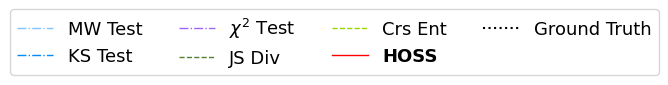

In [3]:
from matplotlib.lines import Line2D

colors = ['#7FC4FD', '#038BFB', '#A065FF', '#548235', '#99D600', 'red', 'black']
oracle_labels = ['MW Test', 'KS Test', '$\chi^2$ Test', 'JS Div', 'Crs Ent', 'HOSS', 'Ground Truth']
linestyles = ['-.', '-.', '-.', '--', '--', '-', ':']
linewidth = 1
markersize = 3
 
labelsize = 10
figsize_para = (0.2, 0.3)

n_items = len(colors)

linewidthlist = [linewidth] * n_items
linewidthlist[-1] = linewidth + 0.5

# define the legends
legend_elements = [
    Line2D([0], [0], 
           color=colors[i], 
           linestyle=linestyles[i], 
           label=oracle_labels[i], 
           linewidth=linewidthlist[i])
    for i in range(n_items)
]
plt.figure(figsize=figsize_para)

legend = plt.legend(ncol=4, handles=legend_elements, loc='center', fontsize=fontsize)
legend_texts = legend.get_texts()
legend_texts[-2].set_weight('bold')
plt.axis('off')
plt.savefig('legend_RQ1_curves.pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)

### Data Analysis

The following code is used to produce data in TABLE II, where the three metrics (i.e., $s^*$, $\delta^*$ and $\sigma^*$) are calculated. The data are directly shown in the output window.


Note that all the following `.csv` files should be traversed.
Format: `xxx_yyy_RQ1_zzz.csv`, where
 
+ `xxx`$\in[$`DO`, `QFT`, `LPR`, `LAF`, `IC`, `WA`$]$, 
+ `yyy`$\in[$`v1`, `v2`, `v3`, `v4`, `v5`$]$, 
+ `zzz`$\in[$`KS Test`, `Chi Squared`, `MW Test`, `JS Div`, `Crs Ent`, `HOSS`$]$. 

In [ ]:
import pandas as pd

def find_stable_point(shots, ave_faults, std_faults, eps_conv=0.5, window=5):
    '''
        This function calculates the involved three metrics
        
        Inputs:
            + shots :      the number of shots
            + ave_faults:  the list of mean values of detected faults 
            + std_faults:  the list of standard derivations of detected faults
            + eps_conv:    the tolerable error limit for the convergency
            + windows:     the length of windows
        
        Outputs:
            + s_star
            + delta_star
            + sigma_star
    '''
    stable_count = 0
    for i in range(1, len(ave_faults)):
        if abs(ave_faults[i] - ave_faults[i-1]) < eps_conv:
            stable_count += 1
        else:
            stable_count = 0                    # if the convergency fails, reset the count
        if stable_count >= window - 1:          # continue to make the criterion true for the window's length
            return shots[i], ave_faults[i], std_faults[i]   # the curve identified as convergency
    return "O/S", ave_faults[i], std_faults[i]              # the curve identified as no convergency

short_names = ['LPR', 'LAF', 'QFT', 'DO', 'IC', 'WA']

versions = ['v1', 'v2', 'v3', 'v4', 'v5']
oracles = ["KS Test", "Chi Squared", "MW Test", "JS Div", "Crs Ent", "HOSS"]
numColoumn = 7

width = 0.8
fontsize = 12.5
labelsize = 10
linewidth = 1
figsize_para = (4.4, 1.8)

for index in range(len(short_names)):
    short_name = short_names[index]
    short_name = short_names[index]
    print("QP: {} \n".format(short_name))

    for version_id, version in enumerate(versions): 
        diaplayed_data = []
        for col, oracle in enumerate(oracles):
            file_path = short_name + '_' + version + '_RQ1_' + oracle + ".csv"
            df = pd.read_csv(file_path)
            shots = df.iloc[:, 0]  
            faults = df.iloc[:, 4]
            stds = df.iloc[:, 6]
            shot_list = list(shots)
            fault_list = list(faults)
            s_stb, fault_stb, sigma_stb = find_stable_point(shot_list, fault_list, stds)
            diaplayed_data.append(s_stb)
            diaplayed_data.append(25-fault_stb)
            diaplayed_data.append(sigma_stb)

        print(*diaplayed_data, sep='\t')


### Plot for Variable Thresholds of SDMs

The following code plots 4 subfigures in Fig.9. These figures show the variation of $\delta^*$ with the thresholds involved in SDMs. 

Before running the code, the `.csv` files should be appended to the current path. Note that all the following `.csv` files should be traversed.

Format: `aaa_bbb_RQ1_ccc_err=ddd.csv` and `aaa_bbb_RQ1_ccc.csv`(i.e., this class of files is the same as the ones used above with the threshold configured as 0.05), where
 
+ `aaa`$\in[$`LPR`, `LAF`$]$, 
+ `bbb`$\in[$`v1`, `v2`, `v3`, `v4`, `v5`$]$, 
+ `ccc`$\in[$`JS Div`, `Crs Ent`$]$,
+ `ddd`$\in[$`0.01`, `0.02`, `0.1`, `0.2`, `0.5`$]$. 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

short_names = ['LPR', 'LAF']
versions = ['v1', 'v2', 'v3', 'v4', 'v5']
colors = ['#87CEFA', '#98FB98', '#FFB678', '#FFC0CB', '#E6E6FA']
oracles = ["JS Div", "Crs Ent"]
thresholds = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]

width = 0.135
fontsize = 13
labelsize = 11
linewidth = 1
figsize_para = (3.5, 2.2)

def find_stable_point(shots, ave_faults, std_faults, eps_conv=0.5, window=5):
    '''
        This function calculates the involved three metrics
        
        Inputs:
            + shots :      the number of shots
            + ave_faults:  the list of mean values of detected faults 
            + std_faults:  the list of standard derivations of detected faults
            + eps_conv:    the tolerable error limit for the convergency
            + windows:     the length of windows
        
        Outputs:
            + s_star
            + delta_star
            + sigma_star
    '''
    stable_count = 0
    for i in range(1, len(ave_faults)):
        if abs(ave_faults[i] - ave_faults[i-1]) < eps_conv:
            stable_count += 1
        else:
            stable_count = 0                    # if the convergency fails, reset the count
        if stable_count >= window - 1:          # continue to make the criterion true for the window's length
            return shots[i], ave_faults[i], std_faults[i]   # the curve identified as convergency
    return "O/S", ave_faults[i], std_faults[i]              # the curve identified as no convergency


x1 = range(len(thresholds))
for index in range(len(short_names)):
    short_name = short_names[index]
    print("QP: {} \n".format(short_name))
    for col, oracle in enumerate(oracles):
        fig, ax = plt.subplots(1, 1, figsize=figsize_para)
        for version_id, version in enumerate(versions): 
            delta_stb_list = []
            for id_th, threshold in enumerate(thresholds):
                if threshold == 0.05:
                    file_name = "{}_{}_RQ1_{}.csv".format(short_name, version, oracle)
                else:
                    file_name = "{}_{}_RQ1_{}_err={}.csv".format(short_name, version, oracle, threshold)
                # read the excel
                df = pd.read_csv(file_name)
                shots = df.iloc[:, 0] 
                ave_faults = df.iloc[:, 4]
                std_faults = df.iloc[:, 6]
                shot_list = list(shots)
                fault_list = list(ave_faults)
                _, fault_stb, _ = find_stable_point(shot_list, fault_list, std_faults)
                delta_stb = 25 - fault_stb
                delta_stb_list.append(delta_stb)

            ax.plot(x1, [0]*len(x1), linewidth=linewidth-0.25, linestyle=':',color='black')
 
            # 添加竖直的虚线
            for xval in [0.65, 1.65, 2.65, 3.65, 4.65]:
                plt.axvline(x=xval, color='gray', linestyle='--', linewidth=0.5)  

            ax.set_yticks(np.arange(-30, 31, 10))   
            ax.set_ylim(-28, 28)
            ax.set_title("{} ({})".format(short_name, oracle), fontsize=fontsize)
            ax.bar([xi + (version_id - 1) * width for xi in x1], 
                    delta_stb_list, 
                    width=width, 
                    color=colors[version_id],
                    edgecolor='black', 
                    linewidth=linewidth)
            ax.set_ylabel('$\delta^{*}$', fontsize=fontsize)
            ax.set_xlabel('thresholds for SDMs', fontsize=fontsize)
            ax.set_xticks([xi + width for xi in x1], thresholds)  
            ax.tick_params(axis='x', labelsize=labelsize)
            ax.tick_params(axis='y', labelsize=labelsize)
            plt.savefig('{}_RQ1_{}_SDMs_thresholds.pdf'.format(short_name, oracle), 
                        dpi=600, bbox_inches='tight', pad_inches=0.1)

Plot for legend for the above variable thresholds.

In [ ]:
import matplotlib.patches as mpatches

versions = ['v1', 'v2', 'v3', 'v4', 'v5']
colors = ['#87CEFA', '#98FB98', '#FFB678', '#FFC0CB', '#E6E6FA']
linewidth = 1
markersize = 3
 
labelsize = 10
figsize_para = (0.2, 0.3)

n_items = len(colors)
 
legend_handles = [mpatches.Patch(facecolor=color, hatch=None, label=label) 
                 for color, label in zip(colors, versions)]
plt.figure(figsize=figsize_para)
legend = plt.legend(ncol=n_items, handles=legend_handles, loc='center', fontsize=fontsize)
plt.axis('off')
plt.savefig('legend_RQ1_thresholds.pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)

## RQ2

### Data Analysis of Statistics

This code displays the data in the file `RQ2_mean_values.xlsx`. The following `.csv` files should be traversed.

Format: `aaa_bbb_RQ2_ccc.csv`, where
 
+ `aaa`$\in[$`DO`, `QFT`, `LPR`, `LAF`, `IC`, `WA`$]$, 
+ `bbb`$\in[$`v1`, `v2`, `v3`, `v4`, `v5`$]$, 
+ `ccc`$\in[$`STFQ`, `STSQ`, `HOSS`$]$.

In [ ]:
import pandas as pd

short_names = ['LPR', 'LAF', 'QFT', 'DO', 'IC', 'WA']
versions = ['v1', 'v2', 'v3', 'v4', 'v5']
oracles = ["STFQ", "STSQ", "HOSS"]

for short_name in short_names:
    print(short_name)
    for ver_id, version in enumerate(versions):
        df_list = [] 
        print('version = {} \n'.format(version))
        for ora_id, oracle in enumerate(oracles):
            file_path = short_name + '_' + version + '_RQ2_' + oracle + ".csv"
            df = pd.read_csv(file_path)
            df_list.append(df)

        shot_list = df_list[0].iloc[:, 0]
        for index, shots in enumerate(shot_list):
            print("shots = {} \n".format(shots))
            print("time")
            temp_time_STFQ = df_list[0].iloc[index, 3]
            temp_time_STSQ = df_list[1].iloc[index, 3]
            temp_time_HOSS = df_list[2].iloc[index, 3]       
            print("{} \t {} \t {}".format(temp_time_STFQ, temp_time_STSQ, temp_time_HOSS))
            print("fault")
            temp_faults_STFQ = df_list[0].iloc[index, 4]
            temp_faults_STSQ = df_list[1].iloc[index, 4]
            temp_faults_HOSS = df_list[2].iloc[index, 4]       
            print("{} \t {} \t {}\n".format(temp_faults_STFQ, temp_faults_STSQ, temp_faults_HOSS))        

This code displays the data in the file `RQ2_fault_statistics.xlsx`.

In [ ]:
import pandas as pd
import ast
from scipy.stats import mannwhitneyu
import pingouin as pg
 
short_names = ['LPR', 'LAF', 'QFT', 'DO', 'IC', 'WA']
versions = ['v1', 'v2', 'v3', 'v4', 'v5']
oracles = ["STFQ", "STSQ", "HOSS"]

for short_name in short_names:
    print('QP = {} \n'.format(short_name))
    for ver_id, version in enumerate(versions):
        df_list = [] 
        print('version = {} \n'.format(version))
        for ora_id, oracle in enumerate(oracles):
            file_path = short_name + '_' + version + '_RQ2_' + oracle + ".csv"
            df = pd.read_csv(file_path)
            df_list.append(df)

        shot_list = df_list[0].iloc[:, 0]
        for index, shots in enumerate(shot_list):
            print("shots = {} \n".format(shots))
            faults_STFQ = df_list[0].iloc[index, 2]
            faults_STSQ = df_list[1].iloc[index, 2]
            faults_HOSS = df_list[2].iloc[index, 2]
            fault_list_STFQ = ast.literal_eval(faults_STFQ)
            fault_list_STSQ = ast.literal_eval(faults_STSQ)
            fault_list_HOSS = ast.literal_eval(faults_HOSS)

            _, pval_STSQ_vs_STFQ = mannwhitneyu(fault_list_STSQ, fault_list_STFQ)
            _, pval_HOSS_vs_STFQ = mannwhitneyu(fault_list_HOSS, fault_list_STFQ)
            _, pval_HOSS_vs_STSQ = mannwhitneyu(fault_list_HOSS, fault_list_STSQ)

            if fault_list_STFQ == fault_list_STSQ:
                effect_STSQ_vs_STFQ = 0
            else:
                effect_STSQ_vs_STFQ = pg.compute_effsize(fault_list_STSQ, fault_list_STFQ, eftype='cohen')
            if fault_list_HOSS == fault_list_STFQ:
                effect_HOSS_vs_STFQ = 0
            else:
                effect_HOSS_vs_STFQ = pg.compute_effsize(fault_list_HOSS, fault_list_STFQ, eftype='cohen')
            if fault_list_HOSS == fault_list_STSQ:
                effect_HOSS_vs_STSQ = 0
            else:
                effect_HOSS_vs_STSQ = pg.compute_effsize(fault_list_HOSS, fault_list_STSQ, eftype='cohen')
            effect_list = [effect_STSQ_vs_STFQ, effect_HOSS_vs_STFQ, effect_HOSS_vs_STSQ]
            
            mag_list = []
            for effect in effect_list:
                abs_scal = abs(effect)
                if abs_scal <= 0.01:
                    mag = '(E)'
                elif abs_scal >= 0.01 and abs_scal < 0.2:
                    mag = '(VS)'
                elif abs_scal >= 0.2 and abs_scal < 0.5:
                    mag = '(S)'
                elif abs_scal >= 0.5 and abs_scal < 0.8:
                    mag = '(M)'
                elif abs_scal >= 0.8 and abs_scal < 1.2:
                    mag = '(L)'
                elif abs_scal >= 1.2:
                    mag = '(VL)'
                mag_list.append(mag)

            print("{} \t {} \t {} \t {} \t {} \t {} \t {} \t {} \t {}".format(pval_STSQ_vs_STFQ, effect_STSQ_vs_STFQ, mag_list[0],
                                                                            pval_HOSS_vs_STFQ, effect_HOSS_vs_STFQ, mag_list[1],
                                                                            pval_HOSS_vs_STSQ, effect_HOSS_vs_STSQ, mag_list[2]))

### Boxplots

The following code plots the boxplot about detected faults of each QP along with each configuration of shots (i.e., 5, 10 ,15). Among $6\times3=18$ boxplots, $6$ subfigures corresponding to $6$ QPs upon $5$ shots are displayed in Fig.10.

The format of involved files: `aaa_bbb_RQ2_ccc.csv`, where
 
+ `aaa`$\in[$`DO`, `QFT`, `LPR`, `LAF`, `IC`, `WA`$]$, 
+ `bbb`$\in[$`v1`, `v2`, `v3`, `v4`, `v5`$]$, 
+ `ccc`$\in[$`STFQ`, `STSQ`, `HOSS`$]$.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ast
from itertools import chain

repeats = 20
width = 0.8
fontsize = 13
labelsize = 11
linewidth = 0.5
figsize_para = (2.4, 2.2)
 
short_names = ['LPR', 'LAF', 'QFT', 'DO', 'IC', 'WA']
versions = ["v1", "v2", "v3", "v4", "v5"]
oracles = ["STFQ", "STSQ", "HOSS"]
shot_list = [5, 10, 15]
label_list = [elem for elem in versions for _ in range(repeats * len(oracles))]
group_list = [oracle for oracle in oracles for _ in range(repeats)] * len(versions)

for index in range(len(short_names)):
    short_name = short_names[index]
    print("QP: {}".format(short_name))
    for index, shots in enumerate(shot_list):
        fault_chain = []

        for ver_id, version in enumerate(versions):
            df_list = [] 
            for ora_id, oracle in enumerate(oracles):
                file_path = short_name + '_' + version + '_RQ2_' + oracle + ".csv"
                df = pd.read_csv(file_path)
                df_list.append(df)

            faults_STFQ = df_list[0].iloc[index, 2]
            faults_STSQ = df_list[1].iloc[index, 2]
            faults_HOSS = df_list[2].iloc[index, 2]
            fault_list_STFQ = ast.literal_eval(faults_STFQ)
            fault_list_STSQ = ast.literal_eval(faults_STSQ)
            fault_list_HOSS = ast.literal_eval(faults_HOSS)
            temp_chain = list(chain(fault_list_STFQ, fault_list_STSQ, fault_list_HOSS))
            fault_chain = fault_chain + temp_chain

            fault_data = {
                "Versions": label_list,
                "Group": group_list,
                "# Faults": fault_chain
            }

        data_df = pd.DataFrame(fault_data)
 
        plt.figure(figsize=figsize_para)
        sns.boxplot(
            x="Versions",
            y="# Faults",
            hue="Group",
            data=data_df,
            width=width,    
            dodge=True,    
            palette=['#BBC400', '#FF8E11', 'red'],
            boxprops=dict(edgecolor='black', linewidth=linewidth),   
            whiskerprops=dict(color="black", linewidth=linewidth),   
            medianprops=dict(color="black", linewidth=linewidth),  
            flierprops=dict(marker='o', markersize=1, linestyle='none', 
                            linewidth=0.5, markeredgewidth=linewidth, markeredgecolor="black"), 
            capprops=dict(linewidth=linewidth, color="black"),  
        )

        plt.title(short_name, fontsize=fontsize)
        plt.legend().remove()
        plt.xticks(fontsize=labelsize)
        plt.yticks(np.arange(0, 27, 5), fontsize=labelsize)
        plt.ylim(0, 27)   
        for xval in [0.5, 1.5, 2.5, 3.5, 4.5]:
            plt.axvline(x=xval, color='gray', linestyle='--', linewidth=0.5)  
        ax = plt.gca()
        ax.set_title(short_name, fontsize=fontsize)
        ax.set_xlabel('versions', fontsize=fontsize)
        ax.set_ylabel('faults in each repeat', fontsize=fontsize)  
        plt.savefig('{}_RQ2_faults_shots={}.pdf'.format(short_name, shots), dpi=600, bbox_inches='tight', pad_inches=0.1)

Plot the legend of boxplots.

In [ ]:
import matplotlib.patches as mpatches
 
figsize_para = (2.2 * 2, 0.3)
colnum = 3
fontsize = 10
 

fig_legend = plt.figure(figsize=figsize_para)
colors = ['#BBC400', '#FF8E11', 'red']
labels2 = ['STFQ', 'STSQ', 'HOSS']
legend_handles2 = [mpatches.Patch(facecolor=color, hatch=None, label=label) 
                for color, label in zip(colors, labels2)]

legend_handles = legend_handles2

ax_legend = fig_legend.add_subplot(111)

ax_legend.axis('off')  
legend = ax_legend.legend(ncol=colnum, handles=legend_handles, loc='center', fontsize=fontsize)
legend_texts = legend.get_texts()
legend_texts[-1].set_weight('bold')
fig_legend.savefig('legend_RQ2.pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)

### Data Analysis of Counts

The code to print the counts that are displayed in TABLE IV. The data are also recorded in `RQ2_counts.xlsx`

The file `RQ2_fault_statistics.xlsx` should be appended to current path.

In [ ]:
import pandas as pd

file_path = "RQ2_fault_statistics.xlsx"
df = pd.read_excel(file_path)
for index in range(3):
    print("shots = {}\n".format(5 * (index + 1)))
    for comp_id, comp_item in enumerate(["STSQ vs. STFQ", "HOSS vs. STFQ", "HOSS vs. STSQ"]):
        print(comp_item)
        pval_list = df.iloc[2:, 2 + 9 * index + comp_id * 3].tolist()
        effect_list = df.iloc[2:, 3 +  9 * index + comp_id * 3].tolist()
        mag_list = df.iloc[2:, 4 +  9 * index + comp_id * 3].tolist()
        len_data = len(pval_list)

        count_pval = sum(float(pval) <= 0.05 for pval in pval_list)
        count_M, count_L, count_VL = 0, 0, 0
        for i in range(len_data):
            mag = mag_list[i].replace(" ", "")
            count_M += float(effect_list[i]) > 0 and mag == '(M)'
            count_L += float(effect_list[i]) > 0 and mag == '(L)'
            count_VL += float(effect_list[i]) > 0 and mag == '(VL)'

        # print the counts
        print("#(p_value <= 0.05) = {}".format(count_pval))
        print("#(effect_size > 0, magnitude = (M)) = {}".format(count_M))
        print("#(effect_size > 0, magnitude = (L)) = {}".format(count_L))
        print("#(effect_size > 0, magnitude = (VL)) = {}".format(count_VL))
        print("")

## RQ3

### Plot for Faults and Time

The code is utilized to plot the subfigures in RQ3, which are displayed in Fig. 11.

The format of involved files: `aaa_v1_RQ3_bbb.csv`, where
 
+ `aaa`$\in[$`DO`, `QFT`, `LPR`, `LAF`, `IC`, `WA`$]$, 
+ `bbb`$\in[$`KS Test`, `Chi Squared`, `MW Test`, `JS Div`, `Crs Ent`, `STFQ`, `STSQ`, `HOSS`$]$.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

short_names = ['LPR', 'LAF', 'QFT', 'DO', 'IC', 'WA']
colors = ['#7FC4FD', '#038BFB', '#A065FF', '#548235', '#99D600', '#BBC400', '#FF8E11', 'red']
oracles = ['MW Test', 'KS Test', 'Chi Squared', 'JS Div', 'Crs Ent', 'STFQ', 'STSQ', 'HOSS']
linestyle_marker = {"NHTs": ['-.', '^'],
                    "SDMs": ['--', 'v'],
                    "STs":  [':', "o"],
                    "HOSS": ['-', '*']}

width = 0.1                    
fontsize = 13
labelsize = 11
linewidth = 1
markersize = 3
figsize_para = (2.4 * 2, 2.8)

for object_id, short_name in enumerate(short_names):
       fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize_para)
       for ora_id, oracle in enumerate(oracles):
              file_path = short_name + '_v1_RQ3_' + oracle + '.csv'
              df = pd.read_csv(file_path)
              x1 = range(len(df))
              
              two_day_secs = 2 * 24 * 3600              # time limit
              if short_name == 'diagonal':
                     ax2.axhline(y=two_day_secs, color='black', linestyle='--', linewidth=0.5)
                     annotation = "Time-out boundary"
                     ax2.annotate(annotation, xy=(3, two_day_secs), xytext=(3, two_day_secs - 100000),
                     fontsize=8,
                     horizontalalignment='center')

              if oracle == "HOSS":
                     templinewidth = linewidth + 0.1
                     tempmarkersize = markersize + 1
              else:
                     templinewidth = linewidth
                     tempmarkersize = markersize

              if oracle in ['MW Test', 'KS Test', 'Chi Squared']:
                     templinestyle = linestyle_marker["NHTs"][0]
                     tempmarker = linestyle_marker["NHTs"][1]
              elif oracle in ['JS Div', 'Crs Ent']:
                     templinestyle = linestyle_marker["SDMs"][0]
                     tempmarker = linestyle_marker["SDMs"][1]
              elif oracle in ['STFQ', 'STSQ']:
                     templinestyle = linestyle_marker["STs"][0]
                     tempmarker = linestyle_marker["STs"][1]
              elif oracle == 'HOSS':
                     templinestyle = linestyle_marker["HOSS"][0]
                     tempmarker = linestyle_marker["HOSS"][1]

              ax1.plot(x1, 
                      df.iloc[:, 4],
                      color=colors[ora_id],
                      linewidth=templinewidth,
                      linestyle=templinestyle,
                      marker=tempmarker,
                      markersize=tempmarkersize)   
              ax1.plot(x1, [25]*len(x1), label='Truth', linewidth=linewidth-0.25, linestyle=':',color='black')

              ax2.plot(x1, 
                      df.iloc[:, 3],
                      color=colors[ora_id],
                      linewidth=templinewidth,
                      linestyle=templinestyle,
                      marker=tempmarker,
                      markersize=tempmarkersize)       
 
              ax1.set_ylim(0, 52)
              ax1.set_yticks(np.arange(0, 52, 5))   

       ax1.set_ylabel('#$faults$', fontsize=fontsize)
       ax1.set_xlabel('qubit numbers', fontsize=fontsize)
       ax1.set_xticks(x1, df.iloc[:, 0])  
       ax1.tick_params(axis='x', labelsize=labelsize)
       ax1.tick_params(axis='y', labelsize=labelsize)

       ax2.set_yscale('log')
       ax2.set_ylabel('$time$ (sec)', fontsize=fontsize)
       ax2.set_xlabel('qubit numbers', fontsize=fontsize)
       ax2.set_xticks(x1, df.iloc[:, 0])   
       ax2.tick_params(axis='x', labelsize=labelsize)
       ax2.tick_params(axis='y', labelsize=labelsize)
 
       plt.subplots_adjust(wspace=0.5)
       plt.suptitle(short_name, fontsize=fontsize, ha='center')
       plt.savefig(short_name+ '_v1_RQ3.pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)



Plot the legend

In [ ]:
from matplotlib.lines import Line2D

colors = ['#7FC4FD', '#038BFB', '#A065FF', '#548235', '#99D600', '#BBC400', '#FF8E11', 'red', 'black']
oracle_labels = ['MW Test', 'KS Test', '$\chi^2$ Test', 'JS Div', 'Crs Ent', 'STFQ', 'STSQ', 'HOSS', 'Ground Truth']
linestyles = ['-.', '-.', '-.', '--', '--', ':', ':', '-', ":"]
markers = ['^', '^', '^', 'v', 'v', 'o', 'o', '*','']

linewidth = 1
markersize = 3
fontsize = 12.5
labelsize = 10
figsize_para = (0.2, 0.3)

n_items = len(colors)

linewidthlist = [linewidth] * n_items
linewidthlist[-2] = linewidth + 0.1
linewidthlist[-1] = linewidth - 0.25
markersizelist = [markersize] * n_items
markersizelist[-2] = markersize + 1

legend_elements = [
    Line2D([0], [0], 
           color=colors[i], 
           linestyle=linestyles[i], 
           label=oracle_labels[i], 
           marker=markers[i],
           linewidth=linewidthlist[i],
           markersize=markersizelist[i])
    for i in range(n_items)
]

plt.figure(figsize=figsize_para)
legend = plt.legend(ncol=5, handles=legend_elements, loc='center', fontsize=fontsize)
legend_texts = legend.get_texts()
legend_texts[-2].set_weight('bold')
plt.axis('off')
plt.savefig('legend_RQ3.pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)